In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import numpy as np
import seaborn as sns
import seaborn as sns
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import optuna
from sklearn.ensemble import RandomForestRegressor
import json
from catboost import CatBoostRegressor


c:\Users\Mohsen\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Load data

data = pd.read_csv("hpc.csv")
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
data.describe()

,C,BFS,FA,W,SP,CA,FAg,Age,CS
count,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000,2171.000000
mean,268.384569,74.372962,66.011515,182.850207,4.704933,998.744357,743.526209,64.479963,37.990470
std,110.122893,99.810911,90.817305,32.948553,5.724433,119.519005,110.597748,92.640602,20.368642
min,70.000000,0.000000,0.000000,105.000000,0.000000,723.000000,280.000000,1.000000,1.100000
25%,180.000000,0.000000,0.000000,159.000000,0.000000,932.000000,684.000000,7.000000,23.695000
50%,250.000000,0.000000,0.000000,182.000000,3.300000,1005.600000,750.000000,28.000000,35.300000
75%,347.000000,141.300000,123.000000,203.100000,8.000000,1097.000000,804.000000,90.000000,49.800000
max,702.000000,440.000000,544.000000,295.000000,35.100000,1218.000000,992.600000,365.000000,124.500000


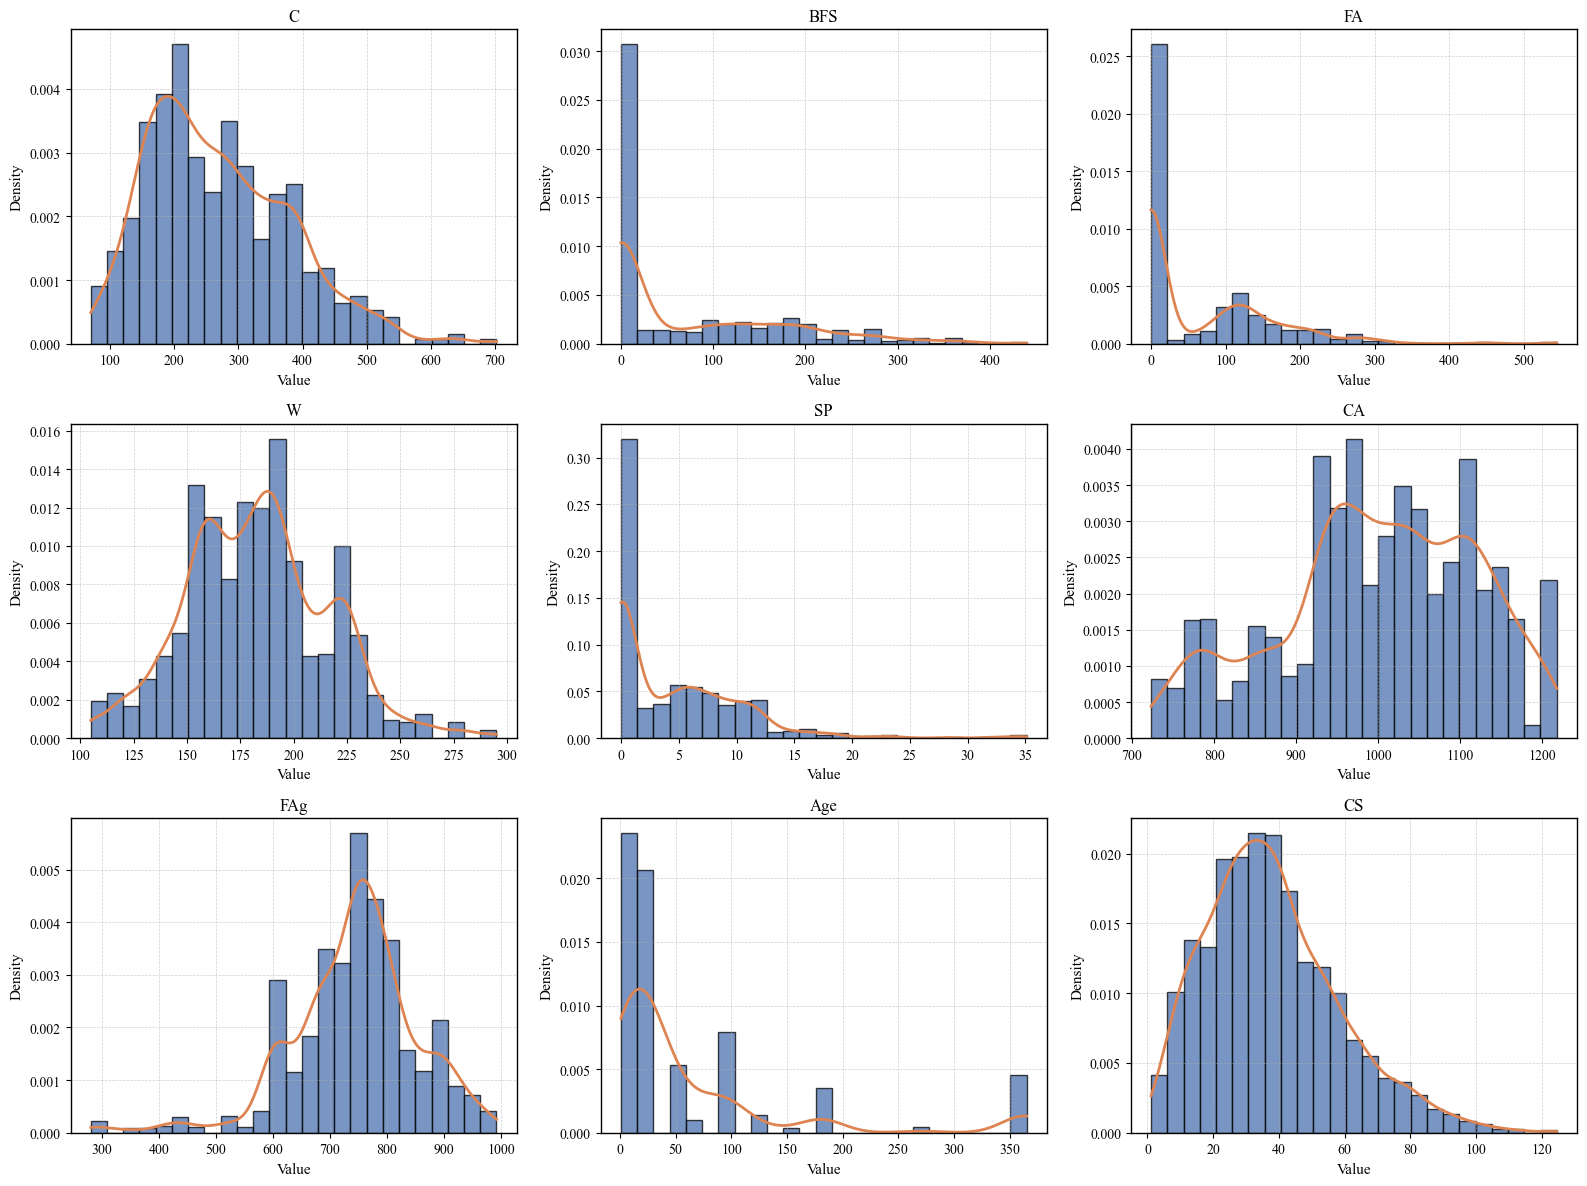

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split


# ---------- Plot settings (Journal style) ----------
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1,
})

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

axes = axes.ravel()

for i in range(9):
    col_data = data.iloc[:, i]

    # Histogram
    axes[i].hist(
        col_data,
        bins=25,
        density=True,
        color="#4C72B0",
        edgecolor="black",
        alpha=0.75
    )

    # KDE
    kde = gaussian_kde(col_data)
    xx = np.linspace(col_data.min(), col_data.max(), 300)
    yy = kde(xx)
    axes[i].plot(xx, yy, color="#DD8452", linewidth=2)

    # Titles & labels
    axes[i].set_title(data.columns[i], pad=6)
    axes[i].set_ylabel("Density")
    axes[i].set_xlabel("Value")

    # Grid (light, journal style)
    axes[i].grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()


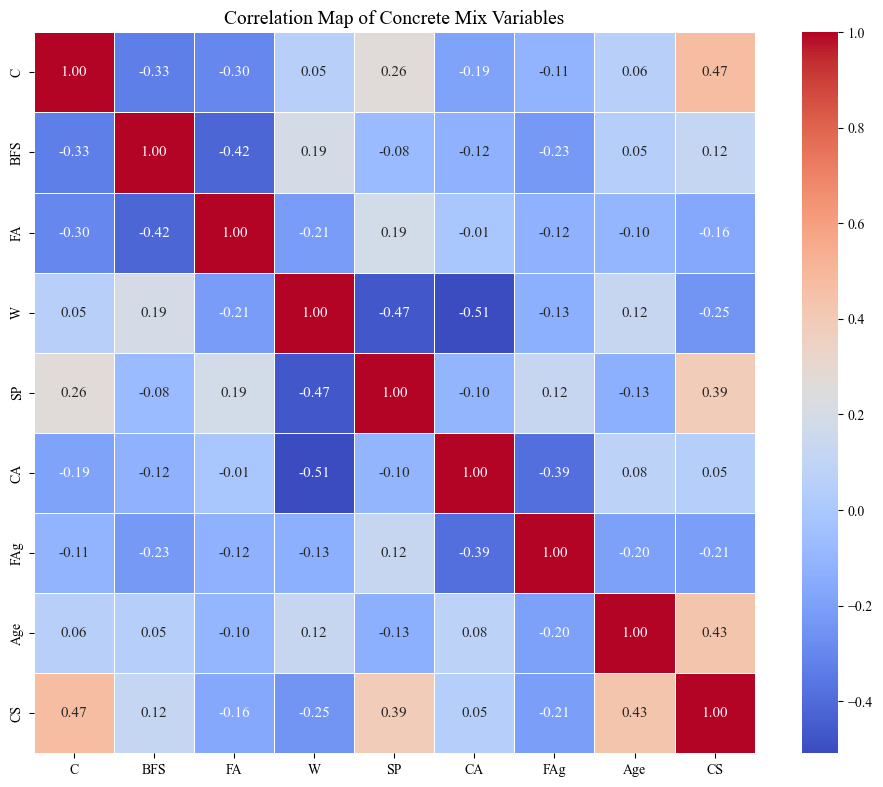

In [6]:
# Correlation map of concrete mix variables and cost. 

corr = data.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Map of Concrete Mix Variables", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Tuning the hyperparameters of the AdaBoostRegressor model

def objective(trial):

    base_estimator = DecisionTreeRegressor(
        max_depth=trial.suggest_int("max_depth", 1, 10),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        random_state=42
    )

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 1.0, log=True),
        "loss": trial.suggest_categorical("loss", ["linear", "square", "exponential"]),
        "estimator": base_estimator,
        "random_state": 42
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_list = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = AdaBoostRegressor(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_list)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
for key, value in study.best_params.items():
    print(f"{key}: {value}")

In [11]:
# Evaluating the AdaBoostRegressor model
final_model = AdaBoostRegressor(
    n_estimators=461,
    learning_rate= 0.011936645,
    loss="square",
    random_state=42,
    estimator=DecisionTreeRegressor(
        max_depth=9,
        min_samples_split=9,
        min_samples_leaf=1,
        random_state=42
    )
)


final_model.fit(X_train, y_train)
models = {}
models['AdaBoostRegressor'] = final_model  
y_pred = final_model.predict(X_test)
y_AdaBoostRegressor=y_pred
model_AdaBoostRegressor=final_model


r2 = r2_score(y_test, y_pred) #Coefficient of determination
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
epsilon = 1e-8   
mean_absolute_relative_error = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))
mean_square_relative_error=np.mean(((y_test - y_pred) / (y_test + epsilon))**2)
Root_mean_squared_relative_error=np.sqrt(mean_square_relative_error)
Relative_root_mean_square_error=rmse/np.sum(y_test)*100
mean_bias_error=np.mean(y_test - y_pred)
max_absolute_relative_error=np.max(np.abs((y_test - y_pred) / (y_test + epsilon)))
std_diff = np.std(y_test - y_pred, ddof=0)
uncertainty_95=np.sqrt(1.96 * (std_diff**2 + rmse**2))
r2, np.corrcoef(y_test, y_pred)[0,1], mse, rmse, mae

(0.9145233247144093,
 0.958183948574123,
 34.277977055464945,
 5.8547397086006265,
 4.257350074277063)

In [ ]:
# Tuning the hyperparameters of the RandomForestRegressor

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_list = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = RandomForestRegressor(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_list)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
for key, value in study.best_params.items():
    print(f"{key}: {value}")


In [13]:
# Evaluating the RandomForestRegressor model
final_model = RandomForestRegressor(
    n_estimators=467,
    max_depth=30,
    min_samples_split=6,
    min_samples_leaf=1,
    max_features='log2',
    bootstrap=False,
    random_state=42,    
)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_RandomForestRegressor=y_pred
model_RandomForestRegressor=final_model

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)
mare = np.mean(np.abs((y_test - y_pred) / y_test))

r2 = r2_score(y_test, y_pred) #Coefficient of determination
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
epsilon = 1e-8   
mean_absolute_relative_error = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))
mean_square_relative_error=np.mean(((y_test - y_pred) / (y_test + epsilon))**2)
Root_mean_squared_relative_error=np.sqrt(mean_square_relative_error)
Relative_root_mean_square_error=rmse/np.sum(y_test)
mean_bias_error=np.mean(y_test - y_pred)
max_absolute_relative_error=np.max(np.abs((y_test - y_pred) / (y_test + epsilon)))
std_diff = np.std(y_test - y_pred, ddof=0)
uncertainty_95=np.sqrt(1.96 * (std_diff**2 + rmse**2))
r2, np.corrcoef(y_test, y_pred)[0,1], mse, rmse, mae

(0.9358867108357265,
 0.9708485326920846,
 25.710801778152845,
 5.070581995999359,
 3.513508697418184)

In [ ]:
# Tuning the hyperparameters of the SVR

from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

def objective(trial):
    params = {
        "C": trial.suggest_float("C", 0.1, 100, log=True),
        "epsilon": trial.suggest_float("epsilon", 0.001, 1.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-4, 1e-1, log=True),
        "kernel": trial.suggest_categorical("kernel", ["rbf", "poly", "sigmoid"])
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_list = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(**params))
        ])

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        y_SVR=y_pred

        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_list)
import optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
for key, value in study.best_params.items():
    print(f"{key}: {value}")


In [14]:
# Evaluating the SVR model

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

final_model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(C=30.61330396, 
                        epsilon=0.013310678,
                        gamma=0.090972353,
                        kernel='rbf'))
        ])


final_model.fit(X_train, y_train)
model_SVR=final_model
y_pred = final_model.predict(X_test)
y_SVR = y_pred
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mare = np.mean(np.abs((y_test - y_pred) / y_test))
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred) #Coefficient of determination
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
epsilon = 1e-8   
mean_absolute_relative_error = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))
mean_square_relative_error=np.mean(((y_test - y_pred) / (y_test + epsilon))**2)
Root_mean_squared_relative_error=np.sqrt(mean_square_relative_error)
Relative_root_mean_square_error=rmse/np.sum(y_test)
mean_bias_error=np.mean(y_test - y_pred)
max_absolute_relative_error=np.max(np.abs((y_test - y_pred) / (y_test + epsilon)))
std_diff = np.std(y_test - y_pred, ddof=0)
uncertainty_95=np.sqrt(1.96 * (std_diff**2 + rmse**2))
r2, np.corrcoef(y_test, y_pred)[0,1], mse, rmse, mae

(0.8652555090764797,
 0.9329097540498317,
 54.03542607143666,
 7.3508792719943825,
 5.264507680230794)

In [ ]:
# Tuning the hyperparameters of the XGBRegressor

from xgboost import XGBRegressor
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "subsample": trial.suggest_float("subsample", 0.3, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "random_state": 42,
        "n_jobs": -1
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_list = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_list)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
for key, value in study.best_params.items():
    print(f"{key}: {value}")


In [15]:
# Evaluating the XGBRegressor model
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
final_model = XGBRegressor(
    n_estimators=1408,
    max_depth=10,
    gamma= 0.496671009,
    colsample_bytree= 0.853814347,
    subsample= 0.404053905,
    min_child_weight=8,
    learning_rate= 0.032692385,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
model_XGBRegressor=final_model
y_pred = final_model.predict(X_test)
y_XGBRegressor=y_pred
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred) #Coefficient of determination
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
epsilon = 1e-8   
mean_absolute_relative_error = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))
mean_square_relative_error=np.mean(((y_test - y_pred) / (y_test + epsilon))**2)
Root_mean_squared_relative_error=np.sqrt(mean_square_relative_error)
Relative_root_mean_square_error=rmse/np.sum(y_test)
mean_bias_error=np.mean(y_test - y_pred)
max_absolute_relative_error=np.max(np.abs((y_test - y_pred) / (y_test + epsilon)))
std_diff = np.std(y_test - y_pred, ddof=0)
uncertainty_95=np.sqrt(1.96 * (std_diff**2 + rmse**2))
r2, np.corrcoef(y_test, y_pred)[0,1], mse, rmse, mae

(0.969240714442291,
 0.9850428491686102,
 12.3351321406319,
 3.5121406777963635,
 2.296532965022556)

In [ ]:
# Tuning the hyperparameters of the MLPRegressor

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_sizes = []

    for i in range(n_layers):
        hidden_sizes.append(trial.suggest_int(f"n_units_layer_{i}", 16, 256))

    hidden_layer_sizes = tuple(hidden_sizes)

    params = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "activation": trial.suggest_categorical("activation", ["relu", "tanh", "logistic"]),
        "solver": trial.suggest_categorical("solver", ["adam", "lbfgs"]),
        "alpha": trial.suggest_float("alpha", 1e-6, 1e-1, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-4, 1e-1, log=True),
        "max_iter": 1000,
        "random_state": 42
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_list = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ann", MLPRegressor(**params))
        ])

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_list)
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
for key, value in study.best_params.items():
    print(f"{key}: {value}")


In [17]:
# Evaluating the MLPRegressor model
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
final_model = MLPRegressor(
    hidden_layer_sizes= (187,71),
    activation= 'tanh',
    solver= 'adam',
    alpha= 0.000218255,
    learning_rate_init= 0.001681669,
    max_iter= 1000,
    random_state= 42
)
final_model = Pipeline([
            ("scaler", StandardScaler()),
            ("ann", MLPRegressor(
                                hidden_layer_sizes= (187,71),
                                activation= 'tanh',
                                solver= 'adam',
                                alpha= 0.000218255,
                                learning_rate_init= 0.001681669,
                                max_iter= 1000,
                                random_state= 42))
        ])
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_MLPRegressor=y_pred
model_MLPRegressor=final_model


mare = np.mean(np.abs((y_test - y_pred) / y_test))
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred) #Coefficient of determination
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
epsilon = 1e-8  
mean_absolute_relative_error = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))
mean_square_relative_error=np.mean(((y_test - y_pred) / (y_test + epsilon))**2)
Root_mean_squared_relative_error=np.sqrt(mean_square_relative_error)
Relative_root_mean_square_error=rmse/np.sum(y_test)
mean_bias_error=np.mean(y_test - y_pred)
max_absolute_relative_error=np.max(np.abs((y_test - y_pred) / (y_test + epsilon)))
std_diff = np.std(y_test - y_pred, ddof=0)
uncertainty_95=np.sqrt(1.96 * (std_diff**2 + rmse**2))
r2, np.corrcoef(y_test, y_pred)[0,1], mse, rmse, mae

(0.9375185536793604,
 0.9685314748331695,
 25.056397856084995,
 5.005636608472992,
 3.715275115581597)

In [ ]:
# Tuning the hyperparameters of the CatBoostRegressor

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "depth": trial.suggest_int("depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 5),
        "random_strength": trial.suggest_float("random_strength", 0, 2),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "RMSE",
        "random_seed": 42,
        "verbose": 0
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_list = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)

        y_pred = model.predict(X_val)
        rmse_list.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmse_list)
import optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
for key, value in study.best_params.items():
    print(f"{key}: {value}")


In [18]:
# Evaluating the CatBoostRegressor model

from catboost import CatBoostRegressor
final_model = CatBoostRegressor(
    iterations= 1150,
    depth= 4,
    learning_rate= 0.114777392,
    l2_leaf_reg= 6.942658041,
    bagging_temperature= 3.673767272,
    random_strength= 1.529709068,
    border_count= 38,
    random_state=42
)

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_CatBoostRegressor=y_pred
model_CatBoostRegressor = final_model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

r2 = r2_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred) #Coefficient of determination
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
epsilon = 1e-8   
mean_absolute_relative_error = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon)))
mean_square_relative_error=np.mean(((y_test - y_pred) / (y_test + epsilon))**2)
Root_mean_squared_relative_error=np.sqrt(mean_square_relative_error)
Relative_root_mean_square_error=rmse/np.sum(y_test)
mean_bias_error=np.mean(y_test - y_pred)
max_absolute_relative_error=np.max(np.abs((y_test - y_pred) / (y_test + epsilon)))
std_diff = np.std(y_test - y_pred, ddof=0)
uncertainty_95=np.sqrt(1.96 * (std_diff**2 + rmse**2))
r2, np.corrcoef(y_test, y_pred)[0,1], mse, rmse, mae

0:	learn: 19.3578931	total: 161ms	remaining: 3m 5s
1:	learn: 18.3505359	total: 165ms	remaining: 1m 34s
2:	learn: 17.5329795	total: 166ms	remaining: 1m 3s
3:	learn: 16.8160731	total: 168ms	remaining: 48.2s
4:	learn: 16.1242769	total: 215ms	remaining: 49.2s
5:	learn: 15.4618194	total: 217ms	remaining: 41.3s
6:	learn: 14.9034683	total: 218ms	remaining: 35.7s
7:	learn: 14.4526829	total: 220ms	remaining: 31.5s
8:	learn: 13.9515834	total: 225ms	remaining: 28.5s
9:	learn: 13.4859572	total: 227ms	remaining: 25.9s
10:	learn: 13.1511583	total: 229ms	remaining: 23.8s
11:	learn: 12.7370645	total: 231ms	remaining: 21.9s
12:	learn: 12.4001754	total: 233ms	remaining: 20.3s
13:	learn: 12.1205809	total: 234ms	remaining: 19s
14:	learn: 11.7733865	total: 238ms	remaining: 18s
15:	learn: 11.5178547	total: 242ms	remaining: 17.2s
16:	learn: 11.2478480	total: 244ms	remaining: 16.3s
17:	learn: 10.9501938	total: 266ms	remaining: 16.8s
18:	learn: 10.7613923	total: 272ms	remaining: 16.2s
19:	learn: 10.5607016	tot

(0.9690822788579777,
 0.9845914857958608,
 12.398668202437216,
 3.5211742647073314,
 2.49572343375952)

In [19]:
models = {
    "XGBRegressor": model_XGBRegressor,
    "MLPRegressor": model_MLPRegressor,
    "SVR": model_SVR,
    "AdaBoostRegressor": model_AdaBoostRegressor,
    "RandomForestRegressor": model_RandomForestRegressor,
    "CatBoostRegressor": model_CatBoostRegressor
}

0:	learn: 19.4512905	total: 1.37ms	remaining: 1.57s
1:	learn: 18.4639274	total: 2.93ms	remaining: 1.68s
2:	learn: 17.6316710	total: 4.37ms	remaining: 1.67s
3:	learn: 16.8835169	total: 5.55ms	remaining: 1.59s
4:	learn: 16.1760645	total: 6.71ms	remaining: 1.54s
5:	learn: 15.5804740	total: 7.87ms	remaining: 1.5s
6:	learn: 15.0065478	total: 10.2ms	remaining: 1.67s
7:	learn: 14.5118594	total: 11.9ms	remaining: 1.69s
8:	learn: 14.0409902	total: 13.2ms	remaining: 1.67s
9:	learn: 13.5802871	total: 14.3ms	remaining: 1.63s
10:	learn: 13.1691146	total: 15.5ms	remaining: 1.6s
11:	learn: 12.7440642	total: 16.6ms	remaining: 1.57s
12:	learn: 12.3487674	total: 17.7ms	remaining: 1.55s
13:	learn: 12.0329883	total: 18.9ms	remaining: 1.53s
14:	learn: 11.7395134	total: 20.1ms	remaining: 1.52s
15:	learn: 11.4519951	total: 21.2ms	remaining: 1.5s
16:	learn: 11.1899075	total: 22.4ms	remaining: 1.49s
17:	learn: 11.0015995	total: 25ms	remaining: 1.57s
18:	learn: 10.8359641	total: 26.6ms	remaining: 1.58s
19:	lear

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (5,).

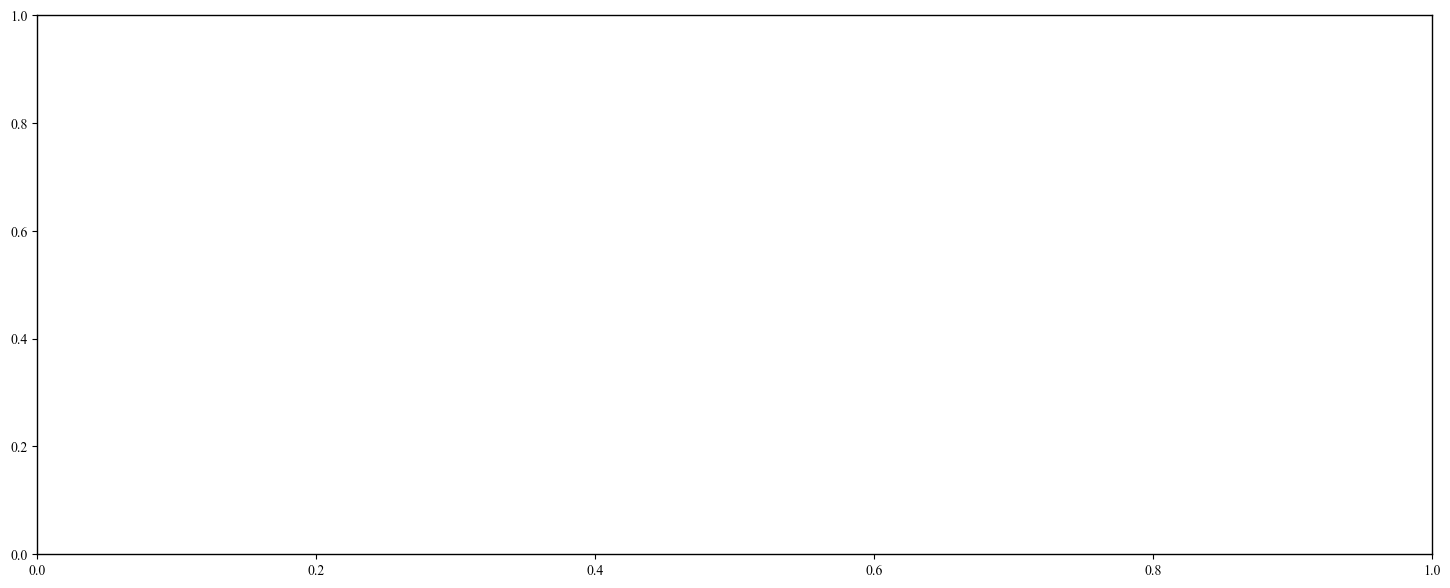

In [20]:
# Comparison of R² scores models across 10-fold cross-validation.

import matplotlib.pyplot as plt
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model_names = list(models.keys())
fold_r2 = {name: [] for name in model_names}


for model_name, model in models.items():
    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), start=1):
        X_train1, X_test1 = X.iloc[train_idx], X.iloc[test_idx]
        y_train1, y_test1 = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train1, y_train1)
        y_pred1 = model.predict(X_test1)
        r2 = r2_score(y_test1, y_pred1)

        fold_r2[model_name].append(r2)



plt.figure(figsize=(18, 7))

n_folds = 10
n_models = len(models)
x = np.arange(n_folds)  
width = 0.15            

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

for i, model_name in enumerate(model_names):
    plt.bar(x + i*width, fold_r2[model_name], width, label=model_name, color=colors[i])

plt.xlabel("Fold Number", fontsize=12)
plt.ylabel("R² Score", fontsize=12)
plt.title("Comparison of 6 Models Across 10 Folds (R² Score)", fontsize=14)

plt.xticks(x + width*2, [f"Fold {i}" for i in range(1, 11)])
plt.legend(title="Models")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Comparison of actual and predicted values for both training and testing datasets.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

final_model = model_AdaBoostRegressor
y_pred = final_model.predict(X_test)

r2_test = r2_score(y_test, y_AdaBoostRegressor)
r2_train = r2_score(y_train, final_model.predict(X_train))

plt.scatter(y_test, y_pred, label='test')
plt.scatter(y_train, final_model.predict(X_train), label='train')

min_val = min(min(y_test), min(y_train))
max_val = max(max(y_test), max(y_train))
x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, 'k--', label='y = x')

plt.plot(x_vals, x_vals * 1.10, 'r--', label='+10% deviation')
plt.plot(x_vals, x_vals * 0.90, 'b--', label='-10% deviation')

textstr = f'R² test = {r2_test:.3f}\nR² train = {r2_train:.3f}'
plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('AdaBoost')
plt.show()

In [ ]:
# Comparison of actual and predicted values for both training and testing datasets.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

final_model = model_RandomForestRegressor
y_pred = final_model.predict(X_test)

r2_test = r2_score(y_test, y_RandomForestRegressor)
r2_train = r2_score(y_train, final_model.predict(X_train))

plt.scatter(y_test, y_pred, label='test')
plt.scatter(y_train, final_model.predict(X_train), label='train')

min_val = min(min(y_test), min(y_train))
max_val = max(max(y_test), max(y_train))
x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, 'k--', label='y = x')

plt.plot(x_vals, x_vals * 1.10, 'r--', label='+10% deviation')
plt.plot(x_vals, x_vals * 0.90, 'b--', label='-10% deviation')

textstr = f'R² test = {r2_test:.3f}\nR² train = {r2_train:.3f}'
plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('RF')
plt.show()

In [ ]:
# Comparison of actual and predicted values for both training and testing datasets.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

final_model = model_SVR
y_pred = final_model.predict(X_test)

r2_test = r2_score(y_test, y_SVR)
r2_train = r2_score(y_train, final_model.predict(X_train))

plt.scatter(y_test, y_pred, label='test')
plt.scatter(y_train, final_model.predict(X_train), label='train')

min_val = min(min(y_test), min(y_train))
max_val = max(max(y_test), max(y_train))
x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, 'k--', label='y = x')

plt.plot(x_vals, x_vals * 1.10, 'r--', label='+10% deviation')
plt.plot(x_vals, x_vals * 0.90, 'b--', label='-10% deviation')

textstr = f'R² test = {r2_test:.3f}\nR² train = {r2_train:.3f}'
plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('SVR')
plt.show()

In [ ]:
# Comparison of actual and predicted values for both training and testing datasets.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

final_model = model_XGBRegressor
y_pred = final_model.predict(X_test)

r2_test = r2_score(y_test, y_XGBRegressor)
r2_train = r2_score(y_train, final_model.predict(X_train))

plt.scatter(y_test, y_pred, label='test')
plt.scatter(y_train, final_model.predict(X_train), label='train')

min_val = min(min(y_test), min(y_train))
max_val = max(max(y_test), max(y_train))
x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, 'k--', label='y = x')

plt.plot(x_vals, x_vals * 1.10, 'r--', label='+10% deviation')
plt.plot(x_vals, x_vals * 0.90, 'b--', label='-10% deviation')

textstr = f'R² test = {r2_test:.3f}\nR² train = {r2_train:.3f}'
plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost')
plt.show()

In [ ]:
# Comparison of actual and predicted values for both training and testing datasets.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

final_model = model_MLPRegressor
y_pred = final_model.predict(X_test)

r2_test = r2_score(y_test, y_MLPRegressor)
r2_train = r2_score(y_train, final_model.predict(X_train))

plt.scatter(y_test, y_pred, label='test')
plt.scatter(y_train, final_model.predict(X_train), label='train')

min_val = min(min(y_test), min(y_train))
max_val = max(max(y_test), max(y_train))
x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, 'k--', label='y = x')

plt.plot(x_vals, x_vals * 1.10, 'r--', label='+10% deviation')
plt.plot(x_vals, x_vals * 0.90, 'b--', label='-10% deviation')

textstr = f'R² test = {r2_test:.3f}\nR² train = {r2_train:.3f}'
plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('ANN')
plt.show()

In [ ]:
# Comparison of actual and predicted values for both training and testing datasets.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

final_model = model_CatBoostRegressor
y_pred = final_model.predict(X_test)

r2_test = r2_score(y_test, y_CatBoostRegressor)
r2_train = r2_score(y_train, final_model.predict(X_train))

plt.scatter(y_test, y_pred, label='test')
plt.scatter(y_train, final_model.predict(X_train), label='train')

min_val = min(min(y_test), min(y_train))
max_val = max(max(y_test), max(y_train))
x_vals = np.linspace(min_val, max_val, 100)

plt.plot(x_vals, x_vals, 'k--', label='y = x')

plt.plot(x_vals, x_vals * 1.10, 'r--', label='+10% deviation')
plt.plot(x_vals, x_vals * 0.90, 'b--', label='-10% deviation')

textstr = f'R² test = {r2_test:.3f}\nR² train = {r2_train:.3f}'
plt.text(0.95, 0.05, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='bottom', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

plt.legend()
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('CatBoost')
plt.show()

In [ ]:
# Taylor diagram 

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# -------------------------
# Taylor Diagram Class
# -------------------------
class TaylorDiagram:
    def __init__(self, refstd, fig=None, rect=111, label='Reference'):
        self.refstd = refstd

        tr = np.pi / 2
        t = np.linspace(0, tr)

        if fig is None:
            fig = plt.figure(figsize=(7, 6))

        self.fig = fig
        self.ax = fig.add_subplot(rect, polar=True)

        # Set limits
        self.ax.set_xlim([0, tr])

        # Correlation labels
        rs = np.concatenate((np.linspace(0, 0.9, 10), [0.95, 1.0]))
        self.ax.set_thetagrids(np.degrees(np.arccos(rs)),
                               labels=[f"{r:.2f}" for r in rs])

        # Radius grid (standard deviation)
        self.ax.set_rgrids(np.linspace(0, refstd * 1.5, 7))

        # Plot reference point
        self.ax.plot(0, refstd, 'ko', label=label)

    def add_sample(self, stddev, corrcoef, label, marker='o', color='r'):
        theta = np.arccos(corrcoef)
        self.ax.plot(theta, stddev, marker=marker, color=color, label=label)

    def add_contours(self, levels=5, **kwargs):
        rs, ts = np.meshgrid(np.linspace(0, self.refstd * 1.5, 100),
                             np.linspace(0, np.pi/2, 100))

        corr = np.cos(ts)
        rmse = np.sqrt(self.refstd**2 + rs**2 - 2*self.refstd*rs*corr)

        contours = self.ax.contour(ts, rs, rmse, levels, **kwargs)
        return contours


In [ ]:
# Taylor diagram 

ref_std = np.std(y_test)
std_pred = np.std(y_pred)
corr = np.corrcoef(y_test, y_pred)[0, 1]

fig = plt.figure(figsize=(7, 6))
dia = TaylorDiagram(ref_std, fig=fig, label="Reference")

dia.add_sample(np.std(y_AdaBoostRegressor), np.corrcoef(y_test, y_AdaBoostRegressor)[0,1], label="AdaBoost", color="green")
dia.add_sample(np.std(y_RandomForestRegressor), np.corrcoef(y_test, y_RandomForestRegressor)[0,1], label="RandomForest", color="orange")
dia.add_sample(np.std(y_SVR), np.corrcoef(y_test, y_SVR)[0,1], label="SVR", color="blue")
dia.add_sample(np.std(y_XGBRegressor), np.corrcoef(y_test, y_XGBRegressor)[0,1], label="XGBoost", color="red")
dia.add_sample(np.std(y_MLPRegressor), np.corrcoef(y_test, y_MLPRegressor)[0,1], label="MLP", color="yellow")
dia.add_sample(np.std(y_CatBoostRegressor), np.corrcoef(y_test, y_CatBoostRegressor)[0,1], label="CatBoost", color="pink")

dia.add_contours(levels=5, colors='0.5')

plt.legend(loc='upper right')
plt.title("Taylor Diagram")
plt.show()

In [ ]:
ref_std, std_pred, corr, np.std(y_AdaBoostRegressor), np.corrcoef(y_test, y_AdaBoostRegressor)[0,1], np.std(y_RandomForestRegressor), np.corrcoef(y_test, y_RandomForestRegressor)[0,1], np.std(y_SVR), np.corrcoef(y_test, y_SVR)[0,1], np.std(y_XGBRegressor), np.corrcoef(y_test, y_XGBRegressor)[0,1], np.std(y_MLPRegressor), np.corrcoef(y_test, y_MLPRegressor)[0,1], np.std(y_CatBoostRegressor), np.corrcoef(y_test, y_CatBoostRegressor)[0,1]

In [ ]:
# hpc
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# HPC Model data with specified order
data = {
    'AdaBoost': {
        'R2': 0.8712785408848976,
        'r': 0.934919665428412,
        'MSE': 34.8669612619576,
        'RMSE': 5.904825252448847,
        'MAE': 4.018362875336771
    },
    'RF': {
        'R2': 0.8978752044365991,
        'r': 0.9514188308631276,
        'MSE': 27.662685889929183,
        'RMSE': 5.259532858527379,
        'MAE': 3.5502451501972643
    },
    'SVR': {
        'R2': 0.826605492069586,
        'r': 0.9094449306547474,
        'MSE': 46.96761233602753,
        'RMSE': 6.853292080163191,
        'MAE': 4.970869310220807
    },
    'XGBoost': {
        'R2': 0.9430101920623648,
        'r': 0.971704893291186,
        'MSE': 15.436908805633607,
        'RMSE': 3.928983177061669,
        'MAE': 2.6047408697217005
    },
    'ANN': {
        'R2': 0.9036603020573442,
        'r': 0.9513303365648808,
        'MSE': 26.095668424264854,
        'RMSE': 5.108391960711791,
        'MAE': 3.474560702049442
    },
    'CatBoost': {
        'R2': 0.9392762646232117,
        'r': 0.9697326539322698,
        'MSE': 16.448322941791726,
        'RMSE': 4.055653207781914,
        'MAE': 2.713028433306617
    }
}

# Fixed model order and colors (same as previous)
model_order = ['AdaBoost', 'RF', 'SVR', 'XGBoost', 'ANN', 'CatBoost']
model_colors = {
    'AdaBoost': '#1f77b4',  # blue
    'RF': '#ff7f0e',        # orange
    'SVR': '#2ca02c',       # green
    'XGBoost': '#d62728',   # red
    'ANN': '#9467bd',       # purple
    'CatBoost': '#8c564b'   # brown
}

# Data normalization
metrics = ['R2', 'r', 'MSE', 'RMSE', 'MAE']

# Calculate min and max for each metric
values = {metric: [data[model][metric] for model in data] for metric in metrics}
min_max = {}

for metric in metrics:
    min_val = min(values[metric])
    max_val = max(values[metric])
    min_max[metric] = (min_val, max_val)

# Print min-max values for reference
print("NORMALIZATION RANGES:")
for metric in metrics:
    print(f"  {metric}: min={min_max[metric][0]:.4f}, max={min_max[metric][1]:.4f}")

# Normalization function
def normalize(value, metric):
    min_val, max_val = min_max[metric]
    if metric in ['MSE', 'RMSE', 'MAE']:  # Lower is better
        return 1 - ((value - min_val) / (max_val - min_val) if max_val != min_val else 0)
    else:  # Higher is better (R2 and r)
        return (value - min_val) / (max_val - min_val) if max_val != min_val else 1

# Normalized data
normalized_data = {}
for model in data:
    normalized_data[model] = [normalize(data[model][metric], metric) for metric in metrics]

# Radar chart setup
categories = ['R²', 'r', 'MSE', 'RMSE', 'MAE']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Close the loop

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(polar=True))

# Plot each model in the fixed order with fixed colors
for model in model_order:
    values_norm = normalized_data[model] + normalized_data[model][:1]  # Close the loop
    ax.plot(angles, values_norm, 'o-', linewidth=2.5, label=model, color=model_colors[model])
    ax.fill(angles, values_norm, alpha=0.1, color=model_colors[model])

# Set category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=14, fontweight='bold')

# Set y-axis limits and labels
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=11)
ax.set_rlabel_position(30)

# Add grid
ax.grid(True, alpha=0.3)

# Title and legend
plt.title('HPC Models Performance Comparison - Radar Chart\n(Normalized Values: Higher is Better)', 
          fontsize=16, fontweight='bold', pad=20)

# Place legend outside the plot with fixed order
handles = [plt.Line2D([0], [0], color=model_colors[model], lw=2.5) for model in model_order]
plt.legend(handles, model_order, loc='upper left', bbox_to_anchor=(1.1, 1.0), 
          fontsize=12, framealpha=0.9)

# Add note about normalization
plt.figtext(0.02, 0.02, 
            'Note: MSE, RMSE, MAE are inverted (lower values become higher)\nR² and r are normalized linearly',
            fontsize=10, style='italic', bbox=dict(facecolor='lightgray', alpha=0.5))

# Display the plot
plt.tight_layout()
plt.show()

# Print original values in the fixed order
print("\n" + "="*70)
print("HPC MODELS - ORIGINAL VALUES".center(70))
print("="*70)

for model in model_order:
    print(f"\n{model}:")
    print("-" * 50)
    for metric in metrics:
        print(f"  {metric:6}: {data[model][metric]:.4f}")

# Find best and worst models
print("\n" + "="*70)
print("SUMMARY".center(70))
print("="*70)

# Calculate average normalized score for each model
avg_scores = {}
for model in model_order:
    avg_scores[model] = sum(normalized_data[model]) / len(normalized_data[model])

best_model = max(avg_scores, key=avg_scores.get)
worst_model = min(avg_scores, key=avg_scores.get)

print(f"\nBest Overall Model: {best_model} (Score: {avg_scores[best_model]:.3f})")
print(f"Worst Overall Model: {worst_model} (Score: {avg_scores[worst_model]:.3f})")

print("\n" + "="*70)
print("RANKING (Best to Worst)".center(70))
print("="*70)

# Sort models by average score
ranked_models = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)
for i, (model, score) in enumerate(ranked_models, 1):
    print(f"{i}. {model}: {score:.3f}")

# Print normalized values for reference
print("\n" + "="*70)
print("NORMALIZED VALUES (1 = Best Performance)".center(70))
print("="*70)

for model in model_order:
    print(f"\n{model}:")
    print("-" * 50)
    for i, metric in enumerate(metrics):
        print(f"  {metric:6}: {normalized_data[model][i]:.4f}")

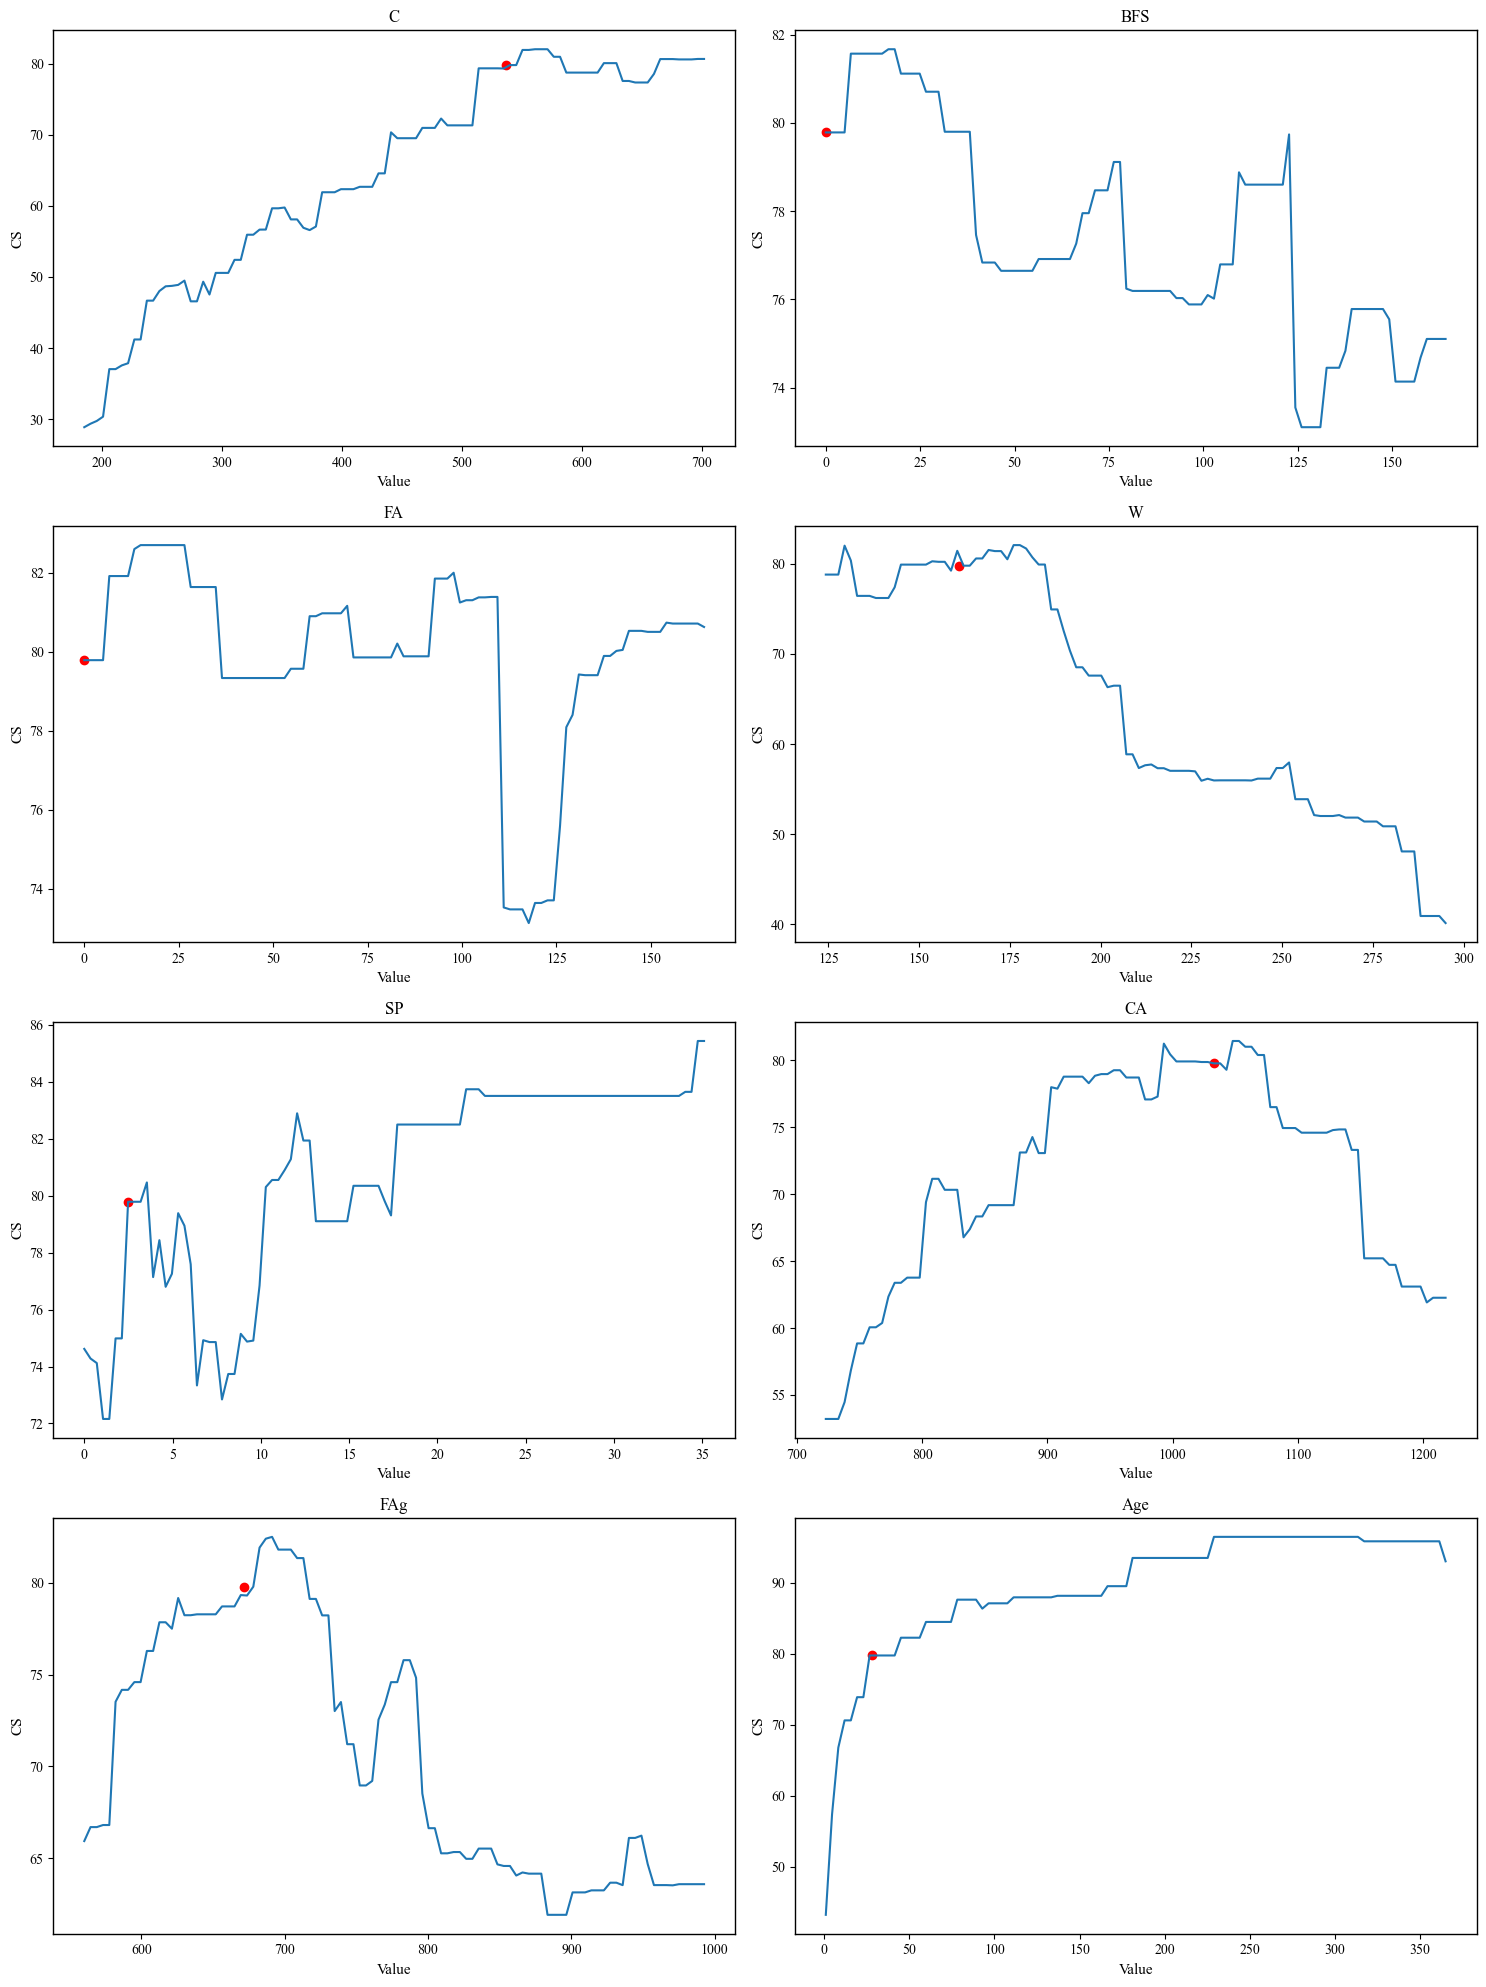

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =====================================================
# sample
# =====================================================
sample = {
    "C": 540,
    "BFS": 0,
    "FA": 0,
    "W": 162,
    "SP": 2.5,
    "CA": 1040,
    "FAg": 676,
    "Age": 28
}

# =====================================================
# Physics
# =====================================================
bounds = {
    "C": (70, 702),
    "BFS": (0, 440),
    "FA": (0, 544),
    "W": (105, 295),
    "SP": (0, 35.1),
    "CA": (723, 1218),
    "FAg": (280, 992.6),
    "Age": (1, 365)
}

# =====================================================
# Specific Gravity
# =====================================================
SG = {
    "C": 3150,
    "BFS": 2800,
    "FA": 2500,
    "W": 1000,
    "SP": 1350,
    "CA": 2500,
    "FAg": 2650
}

# =====================================================
# Normal
# =====================================================
def normalize_to_one_m3(sample):

    s = sample.copy()

    total_volume = (
        s["C"]   / SG["C"] +
        s["BFS"] / SG["BFS"] +
        s["FA"]  / SG["FA"] +
        s["W"]   / SG["W"] +
        s["SP"]  / SG["SP"] +
        s["CA"]  / SG["CA"] +
        s["FAg"] / SG["FAg"]
    )

    factor = 1.0 / total_volume

    for f in ["C", "BFS", "FA", "W", "SP", "CA", "FAg"]:
        s[f] *= factor

    return s

# =====================================================
# Binder
# =====================================================
def compute_binder(sample):
    return sample["C"] + sample["BFS"] + sample["FA"]

# =====================================================
# Allowable
# =====================================================
def feasible_range(feature, sample):

    s = sample.copy()

    def check(x):

        s2 = s.copy()
        s2[feature] = x

        s2 = normalize_to_one_m3(s2)

        C = s2["C"]
        BFS = s2["BFS"]
        FA = s2["FA"]
        W = s2["W"]
        SP = s2["SP"]
        CA = s2["CA"]
        FAg = s2["FAg"]

        binder = C + BFS + FA

        # bounds
        if not (bounds["C"][0] <= C <= bounds["C"][1]): return False
        if not (bounds["BFS"][0] <= BFS <= bounds["BFS"][1]): return False
        if not (bounds["FA"][0] <= FA <= bounds["FA"][1]): return False
        if not (bounds["W"][0] <= W <= bounds["W"][1]): return False
        if not (bounds["SP"][0] <= SP <= bounds["SP"][1]): return False
        if not (bounds["CA"][0] <= CA <= bounds["CA"][1]): return False
        if not (bounds["FAg"][0] <= FAg <= bounds["FAg"][1]): return False
        if not (bounds["Age"][0] <= s2["Age"] <= bounds["Age"][1]): return False

        # constraints
        if binder <= 0: return False
        if BFS / binder > 0.61: return False
        if FA / binder > 0.61: return False
        if W / binder < 0.23 or W / binder > 0.90: return False
        if C <= 0: return False
        if SP / C > 0.13: return False
        if CA / binder < 1.18 or CA / binder > 5.62: return False
        if (CA + FAg) <= 0: return False
        if FAg / (CA + FAg) < 0.35 or FAg / (CA + FAg) > 0.54: return False

        return True

    grid = np.linspace(bounds[feature][0], bounds[feature][1], 2000)
    valid = [x for x in grid if check(x)]

    if len(valid) == 0:
        return None, None

    return min(valid), max(valid)

# =====================================================
# model = model_XGBRegressor

# =====================================================
#  CSV
# =====================================================
features = list(sample.keys())

#fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

sample_norm = normalize_to_one_m3(sample)

base_pred = model.predict(
    np.array(list(sample_norm.values())).reshape(1, -1)
)[0]

for i, f in enumerate(features):

    ax = axes[i]

    fmin, fmax = feasible_range(f, sample)

    if fmin is None:
        ax.set_title(f"{f} (No feasible range)")
        continue

    x_vals = np.linspace(fmin, fmax, 100)
    preds = []

    for x in x_vals:

        s = sample.copy()
        s[f] = x

        s = normalize_to_one_m3(s)

        inp = np.array(list(s.values())).reshape(1, -1)

        preds.append(model.predict(inp)[0])

    # =========================
    # CSV OUTPUT
    # =========================
    df = pd.DataFrame({
        "x": x_vals,
        "y": preds
    })

    df.to_csv(f"sensitivity_{f}.csv", index=False)

    # =========================
    # PLOT
    # =========================
    ax.plot(x_vals, preds)

    ax.scatter(
        [sample_norm[f]],
        [base_pred],
        color='red'
    )

    ax.set_title(f)
    ax.set_xlabel("Value")
    ax.set_ylabel("CS")

plt.tight_layout()
plt.show()